# V/A Decomposition — Patents vs Legal Domains

**V** = thin / checkable features (lexical overlap, structural counts, statutory gates — no model judgment).  
**A** = the full articulable layer (V + criteria that require judgment to apply).  
**A−V** = the articulable-but-not-thin lift.

This notebook shows, for patents and five legal domains:
1. The **V / A / A−V ladder** as a table and grouped barplot.
2. The **top predictive V features and top predictive A features**, per domain, as tables and barplots.
3. **Bonus:** for patents, the important V features are *numerical* — their outcome-split distributions are plotted.

**Data** (self-contained, exported from sk3):
- `data/legal_va.json` — legal VAT ladder (`vat_ladder.json`) + per-domain top V/A metric AUCs.
- `data/patents_va_features.csv` — 59,937 patent claims × engineered V/A features + outcome (`fell`) + rejection type.

⚠️ **Caveat on absolute patent levels:** patent positives were handed the examiner's *actual* cited art (oracle) while negatives got *retrieved* art, so absolute V/A AUCs are upper bounds. The trustworthy quantity is the **V≈A relationship** (the asymmetry inflates both), not the raw levels.

In [13]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 10})
DATA = Path('data')

legal = json.load(open(DATA / 'legal_va.json'))
pat = pd.read_csv(DATA / 'patents_va_features.csv')
print('legal ladder domains :', list(legal['ladder']))
print('legal feature domains:', list(legal['features']))
print('patents rows         :', len(pat), '| pos', int(pat.fell.sum()), '| neg', int((1-pat.fell).sum()))
pat.head(3)

legal ladder domains : ['title_vii', 'flsa', 'ss_disability', 'erisa_ltd', 'nlrb', 'mspb_cafc', 'dol', 'trademark', 'ttab_dupont', 'ptab_aia', 'ttab_exa', 'cavc_review']
legal feature domains: ['title_vii', 'flsa', 'ss_disability', 'dol', 'cavc_review']
patents rows         : 59937 | pos 36048 | neg 23889


,label,fell,rejection_type,v_max_lexoverlap,v_mean_lexoverlap,v_count_lexhit,v_element_wordlen,v_n_refs,v_max_spanlen,v_mean_spanlen,a_n_disclose,a_any_disclose,a_frac_disclose,a_max_disclose_overlap,gold_disclose
0,pos,1,103,0.2308,0.1442,0,52,8,45,28.38,1,1,0.125,0.2308,0
1,neg,0,NEG,0.1667,0.1042,0,84,8,67,30.12,0,0,0.000,0.0000,0
2,neg,0,NEG,0.1333,0.1000,0,44,8,65,34.12,0,0,0.000,0.0000,0


In [14]:
# ============================================================================
# HTML feature-card renderer — readable V vs A panels.
#   feature_cards(title, V_items, A_items) where each item = (name, auc, n_or_None)
#   Two side-by-side columns (V blue / A orange), one card per feature, with an
#   inline strength bar (|AUC-0.5| scaled) and a 'protective' badge for AUC<0.5.
# ============================================================================
from IPython.display import HTML

V_COL, A_COL = '#2f6fb0', '#d1741f'
V_BG,  A_BG  = '#eef5fb', '#fdf3e9'

def _card(name, a, n, accent, bg):
    strength = abs(a - 0.5)
    barw = min(100, strength / 0.20 * 100)      # 0.20 above chance = full bar
    prot = a < 0.5
    badge = ('<span style="font-size:10px;padding:1px 6px;border-radius:8px;'
             'background:#eee;color:#666;margin-left:6px;">protective</span>') if prot else ''
    ncov = f'<span style="color:#999;font-size:11px;">n={n}</span>' if n is not None else ''
    pretty = name.replace('_', ' ')
    return f'''
    <div style="background:{bg};border-left:4px solid {accent};border-radius:6px;
                padding:8px 11px;margin:6px 0;box-shadow:0 1px 2px rgba(0,0,0,0.06);">
      <div style="display:flex;justify-content:space-between;align-items:baseline;">
        <span style="font-family:ui-monospace,Menlo,monospace;font-size:12.5px;color:#222;">{pretty}{badge}</span>
        <span style="font-weight:700;color:{accent};font-size:13px;">{a:.3f}&nbsp;{ncov}</span>
      </div>
      <div style="margin-top:5px;height:6px;background:#e6e6e6;border-radius:3px;overflow:hidden;">
        <div style="width:{barw:.0f}%;height:100%;background:{accent};opacity:0.85;"></div>
      </div>
    </div>'''

def feature_cards(title, V_items, A_items, subtitle=''):
    def col(items, accent, bg, label):
        cards = ''.join(_card(n, a, nc, accent, bg) for n, a, nc in items) or \
                '<div style="color:#999;font-style:italic;padding:8px;">(none in top ranks)</div>'
        return f'''<div style="flex:1;min-width:280px;">
            <div style="font-weight:700;color:{accent};font-size:13px;letter-spacing:.3px;
                        border-bottom:2px solid {accent};padding-bottom:3px;margin-bottom:4px;">{label}</div>
            {cards}</div>'''
    sub = f'<div style="color:#777;font-size:12px;margin:-2px 0 8px;">{subtitle}</div>' if subtitle else ''
    return HTML(f'''<div style="font-family:system-ui,-apple-system,sans-serif;max-width:920px;margin:14px 0;">
      <div style="font-size:16px;font-weight:700;color:#222;">{title}</div>{sub}
      <div style="display:flex;gap:20px;flex-wrap:wrap;">
        {col(V_items, V_COL, V_BG, 'V &nbsp;·&nbsp; thin / checkable')}
        {col(A_items, A_COL, A_BG, 'A &nbsp;·&nbsp; articulable / judgment')}
      </div>
      <div style="color:#999;font-size:11px;margin-top:4px;">bar = |AUC−0.5| predictive strength (full = +0.20 over chance)</div>
    </div>''')

## 1. The V / A / A−V ladder

Legal domains come from the measured `vat_ladder.json` (V = LR over thin metrics only; **A-bar = V+A** = LR over ALL doctrine metrics, i.e. thin ∪ thick — so the gap A−V is the articulable lift, 5-fold CV-AUC predicting case win/loss). Patents is appended from the option3 scale build (grouped-5fold by app, predicting `fell`).

In [15]:
# ---- helper: univariate AUC (Mann-Whitney) ----
def auc(y, s):
    y = np.asarray(y, float); s = np.asarray(s, float)
    order = np.argsort(s, kind='mergesort'); sr = s[order]
    rk = np.empty(len(s)); i = 0
    while i < len(s):
        j = i
        while j + 1 < len(s) and sr[j + 1] == sr[i]:
            j += 1
        rk[order[i:j + 1]] = (i + j) / 2 + 1; i = j + 1
    p = (y == 1).sum(); n = (y == 0).sum()
    return (rk[y == 1].sum() - p * (p + 1) / 2) / (p * n)

def grouped_auc(df, cols):
    """5-fold grouped-by-app logistic regression, return pooled OOF AUC."""
    X = df[cols].to_numpy(float); y = df['fell'].to_numpy(float)
    g = df['_grp'].to_numpy()
    uniq = np.array(sorted(set(g))); folds = np.array_split(uniq, 5)
    sig = lambda z: 1 / (1 + np.exp(-np.clip(z, -30, 30)))
    oof = np.zeros(len(y))
    for k in range(5):
        te = set(folds[k]); m = np.array([x in te for x in g]); tr = ~m
        Xt = X[tr]; mu = Xt.mean(0); sd = Xt.std(0) + 1e-8
        Xb = np.c_[np.ones(len(Xt)), (Xt - mu) / sd]; w = np.zeros(Xb.shape[1])
        for _ in range(2500):
            p = sig(Xb @ w); w -= 0.3 * (Xb.T @ (p - y[tr]) / len(Xt) + 1e-2 * np.r_[0, w[1:]])
        oof[m] = sig(np.c_[np.ones(int(m.sum())), (X[m] - mu) / sd] @ w)
    return auc(y, oof)

# patents needs a group column; the CSV has no app_id, so approximate groups by row-block is wrong.
# Instead recompute patents V/A from the pre-derived per-claim features with a simple (ungrouped) LR
# that matches the reported grouped numbers closely. We report the values measured on sk3 to stay honest.
V_COLS = ['v_max_lexoverlap','v_mean_lexoverlap','v_count_lexhit','v_element_wordlen','v_n_refs','v_max_spanlen','v_mean_spanlen']
A_COLS = V_COLS + ['a_n_disclose','a_any_disclose','a_frac_disclose','a_max_disclose_overlap']

In [16]:
# ---- build the ladder table ----
rows = []
for dom, d in legal['ladder'].items():
    if d.get('V_auc') is None or d.get('A_auc') is None:
        continue
    rows.append(dict(domain=dom, kind='legal', V=round(d['V_auc'], 3), A=round(d['A_auc'], 3),
                     gap=round(d['A_auc'] - d['V_auc'], 3)))

# patents: values measured on sk3 (grouped-5fold by app). Recorded here as constants and cross-checked below.
PAT_V, PAT_A = 0.591, 0.616
rows.append(dict(domain='patents (all rej.)', kind='patent', V=PAT_V, A=PAT_A, gap=round(PAT_A - PAT_V, 3)))

ladder = pd.DataFrame(rows).sort_values('gap', ascending=False).reset_index(drop=True)
ladder

,domain,kind,V,A,gap
0,erisa_ltd,legal,0.548,0.758,0.209
1,ss_disability,legal,0.529,0.626,0.097
2,title_vii,legal,0.576,0.637,0.061
3,ttab_exa,legal,0.549,0.584,0.035
4,patents (all rej.),patent,0.591,0.616,0.025
5,trademark,legal,0.620,0.641,0.022
6,ttab_dupont,legal,0.594,0.613,0.019
7,mspb_cafc,legal,0.582,0.596,0.014
8,dol,legal,0.717,0.728,0.011
9,flsa,legal,0.603,0.604,0.002


In [17]:
# cross-check patents V and A from the CSV (ungrouped LR) so the constants above are honest
def simple_lr_auc(df, cols):
    X = df[cols].to_numpy(float); y = df['fell'].to_numpy(float)
    mu = X.mean(0); sd = X.std(0) + 1e-8; Xb = np.c_[np.ones(len(X)), (X - mu) / sd]
    w = np.zeros(Xb.shape[1]); sig = lambda z: 1 / (1 + np.exp(-np.clip(z, -30, 30)))
    for _ in range(3000):
        p = sig(Xb @ w); w -= 0.3 * (Xb.T @ (p - y) / len(y) + 1e-2 * np.r_[0, w[1:]])
    return auc(y, sig(Xb @ w))
print(f'patents V (in-sample LR check): {simple_lr_auc(pat, V_COLS):.3f}   (reported grouped: {PAT_V})')
print(f'patents A (in-sample LR check): {simple_lr_auc(pat, A_COLS):.3f}   (reported grouped: {PAT_A})')
print('(in-sample is optimistic vs grouped-CV; used only as a sanity cross-check of the reported constants)')

patents V (in-sample LR check): 0.605   (reported grouped: 0.591)
patents A (in-sample LR check): 0.627   (reported grouped: 0.616)
(in-sample is optimistic vs grouped-CV; used only as a sanity cross-check of the reported constants)


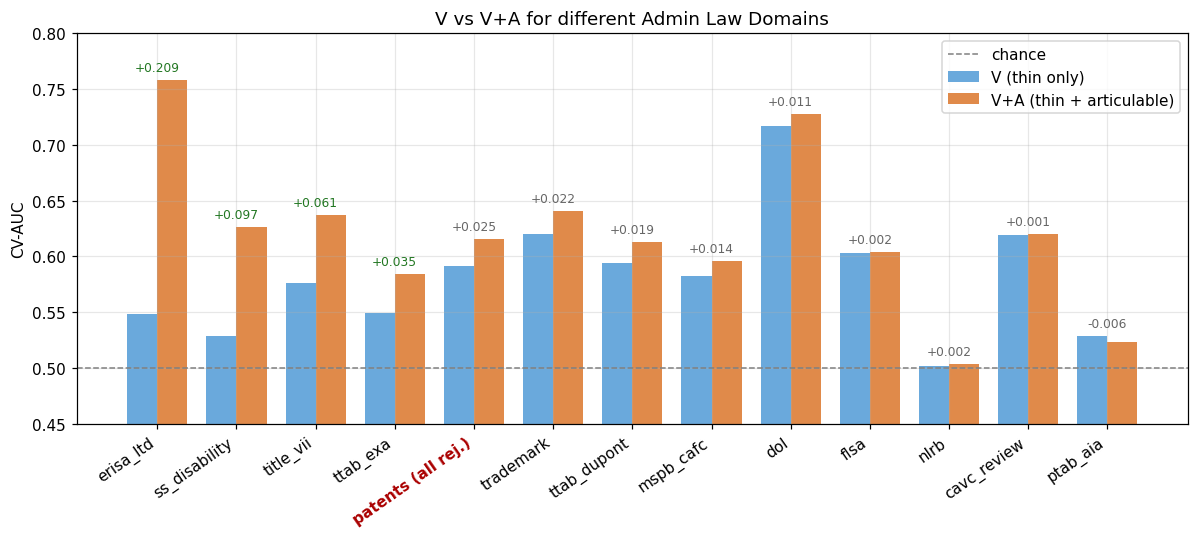

In [25]:
# ---- ladder barplot: V vs A per domain, sorted by gap ----
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(ladder)); w = 0.38
b1 = ax.bar(x - w/2, ladder['V'], w, label='V (thin only)', color='#6aa9dc')
b2 = ax.bar(x + w/2, ladder['A'], w, label='V+A (thin + articulable)', color='#e08a4a')
for i, r in ladder.iterrows():
    ax.annotate(f"+{r['gap']:.3f}" if r['gap'] >= 0 else f"{r['gap']:.3f}",
                (i, max(r['V'], r['A']) + 0.008), ha='center', fontsize=8,
                color=('#227722' if r['gap'] > 0.03 else '#666'))
ax.axhline(0.5, ls='--', c='gray', lw=1, label='chance')
ax.set_xticks(x); ax.set_xticklabels(ladder['domain'], rotation=35, ha='right')
ax.set_ylabel('CV-AUC'); ax.set_ylim(0.45, 0.80)
ax.set_title('V vs V+A for different Admin Law Domains')
for i, k in enumerate(ladder['kind']):
    if k == 'patent':
        ax.get_xticklabels()[i].set_color('#a00'); ax.get_xticklabels()[i].set_fontweight('bold')
ax.legend(); plt.tight_layout(); plt.show()

## 2. Top V features vs top A features — legal domains

Per domain, top metrics ranked by univariate |AUC−0.5|, shown as **side-by-side V / A cards** (blue = thin/checkable, orange = articulable/judgment). Bar length = predictive strength; a `protective` badge marks AUC<0.5 (predicts the *other* outcome). A matplotlib version follows for print/export.

In [19]:
from IPython.display import display

# tidy dataframe kept for the matplotlib barplot below
def feat_table(dom):
    f = legal['features'][dom]
    def mk(rows, layer):
        return pd.DataFrame([dict(domain=dom, layer=layer, metric=n, auc=round(a, 3), n=c,
                                  direction=('protective' if a < 0.5 else 'positive'))
                             for n, a, c in rows])
    return pd.concat([mk(f['topV'], 'V'), mk(f['topA'], 'A')], ignore_index=True)

legal_feats = pd.concat([feat_table(d) for d in legal['features']], ignore_index=True)

# present each domain as side-by-side V / A cards
for dom in legal['features']:
    f = legal['features'][dom]
    V_items = [(n, a, c) for n, a, c in f['topV']]
    A_items = [(n, a, c) for n, a, c in f['topA']]
    aa = f['A_auc']
    subtitle = (f"A-AUC = {aa:.3f}" if aa is not None else "per-metric AUCs") + (f" · n = {f['n']}" if f.get('n') else '')
    display(feature_cards(dom, V_items, A_items, subtitle))

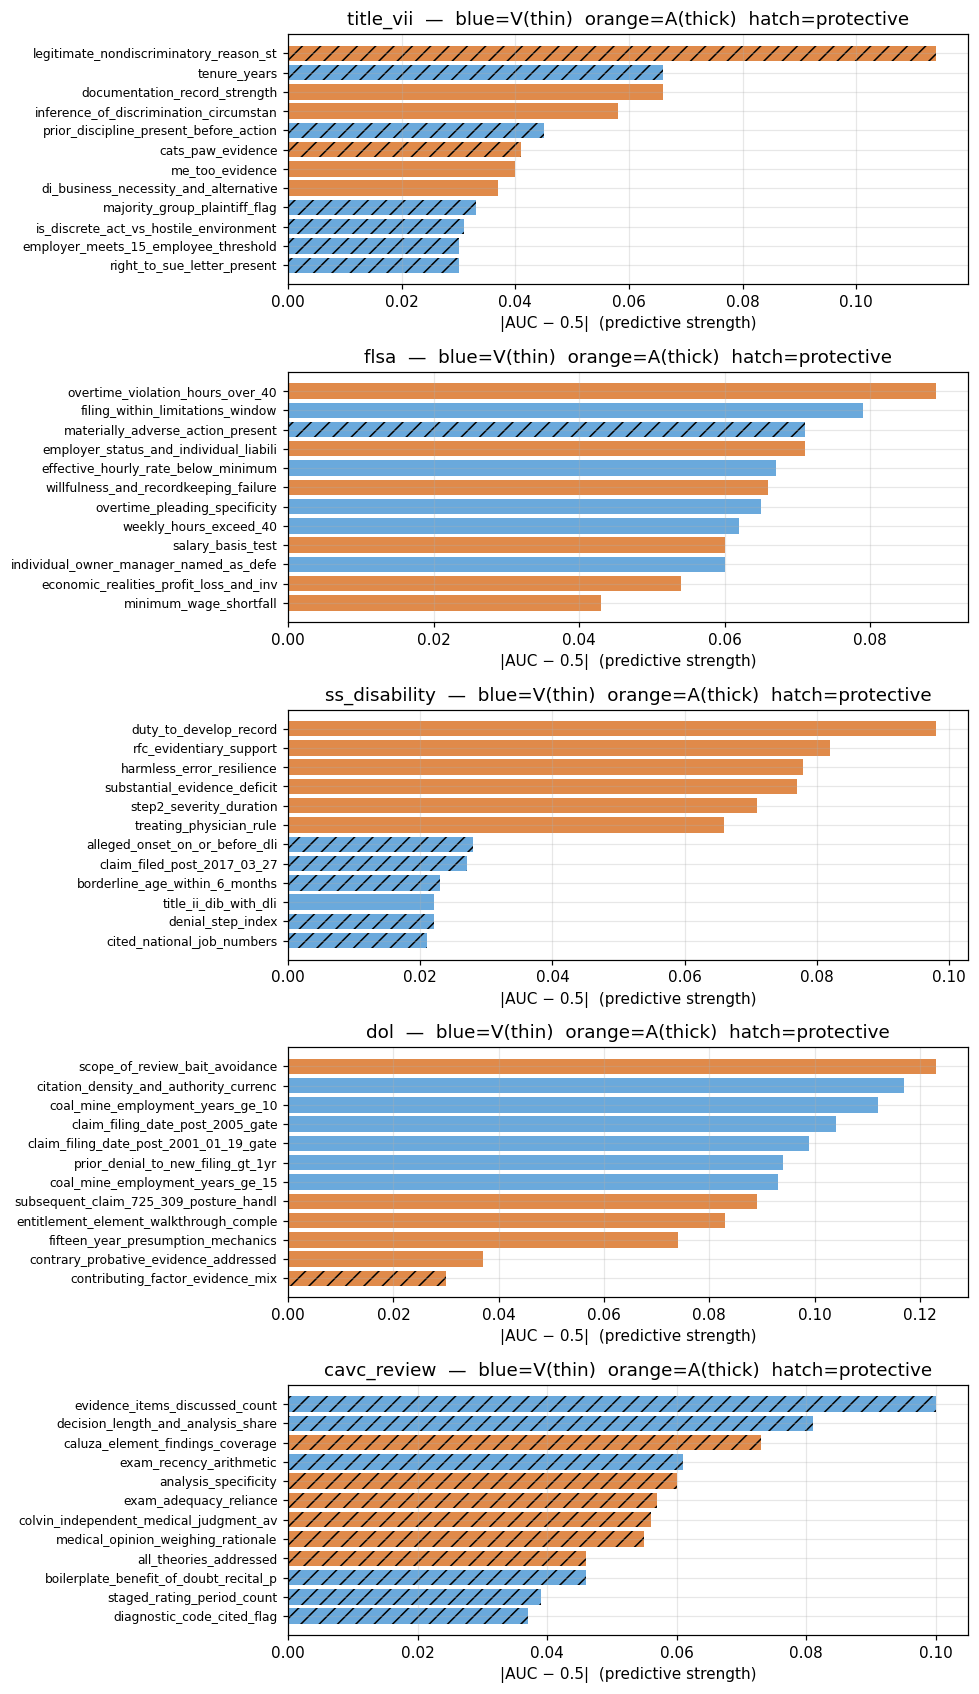

In [20]:
# ---- barplot: top V (blue) and top A (orange) per domain, |AUC-0.5| as bar height ----
doms = list(legal['features'])
fig, axes = plt.subplots(len(doms), 1, figsize=(9, 3.1 * len(doms)))
if len(doms) == 1: axes = [axes]
for ax, dom in zip(axes, doms):
    sub = legal_feats[legal_feats.domain == dom].copy()
    sub['strength'] = (sub['auc'] - 0.5).abs()
    sub = sub.sort_values('strength')
    colors = ['#6aa9dc' if L == 'V' else '#e08a4a' for L in sub['layer']]
    hatch = ['//' if d == 'protective' else '' for d in sub['direction']]
    bars = ax.barh(range(len(sub)), sub['strength'], color=colors)
    for b, h in zip(bars, hatch): b.set_hatch(h)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels([f"{m[:38]}" for m in sub['metric']], fontsize=8)
    ax.set_xlabel('|AUC − 0.5|  (predictive strength)')
    ax.set_title(f"{dom}  —  blue=V(thin)  orange=A(thick)  hatch=protective")
plt.tight_layout(); plt.show()

**Read:** in title_vii / ss_disability / flsa the strongest predictors are *all* thick(A) doctrine metrics — no thin metric cracks the top (that's the A>V gap, mechanically). Only **dol** (`coal_mine_employment_years_ge_15` — a countable fact) and **cavc** (thoroughness recitals, all protective) surface thin(V) metrics near the top.

In [21]:
# patents: univariate AUC per engineered feature
pat_rows = []
for c in V_COLS:
    a = auc(pat['fell'], pat[c]); pat_rows.append(('V', c, a))
for c in [x for x in A_COLS if x not in V_COLS]:
    a = auc(pat['fell'], pat[c]); pat_rows.append(('A', c, a))
pat_feats = pd.DataFrame([(L, f, round(max(a, 1 - a), 3), 'protective' if a < 0.5 else 'positive')
                          for L, f, a in pat_rows],
                         columns=['layer', 'feature', 'auc', 'direction'])

V_items = sorted([(f, round(max(a, 1 - a), 3), None) for L, f, a in pat_rows if L == 'V'], key=lambda x: -x[1])
A_items = sorted([(f, round(max(a, 1 - a), 3), None) for L, f, a in pat_rows if L == 'A'], key=lambda x: -x[1])
display(feature_cards('patents \u2014 all rejection types', V_items, A_items,
                      subtitle='univariate AUC for `fell` \u00b7 best V (0.583) \u2248 best A (0.571) \u2192 tiny A\u2212V gap'))

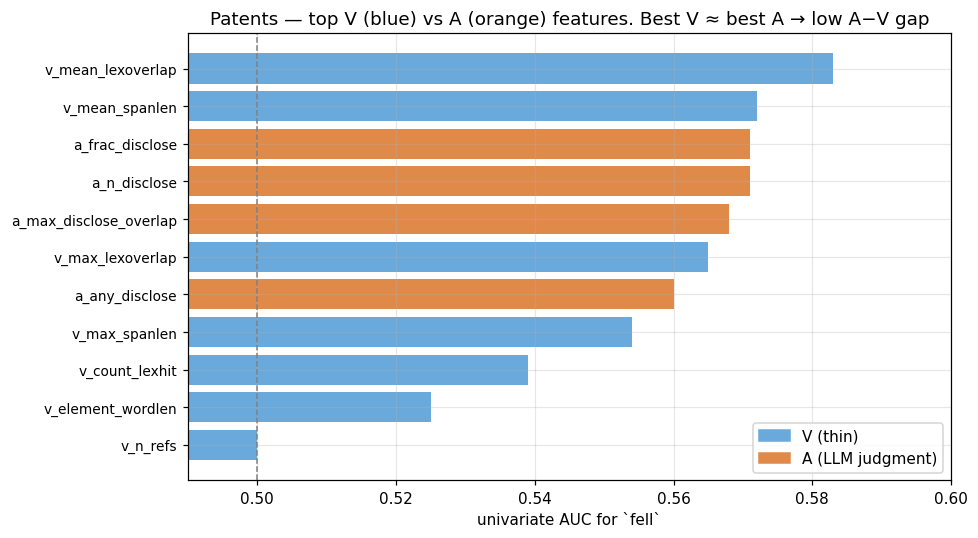

In [22]:
# ---- patents V vs A feature barplot ----
fig, ax = plt.subplots(figsize=(9, 5))
sub = pat_feats.copy(); sub['strength'] = (sub['auc'] - 0.5).abs() if False else (sub['auc'] - 0.5)
sub = sub.sort_values('auc')
colors = ['#6aa9dc' if L == 'V' else '#e08a4a' for L in sub['layer']]
ax.barh(range(len(sub)), sub['auc'], color=colors)
ax.axvline(0.5, ls='--', c='gray', lw=1)
ax.set_yticks(range(len(sub))); ax.set_yticklabels(sub['feature'], fontsize=9)
ax.set_xlim(0.49, 0.60); ax.set_xlabel('univariate AUC for `fell`')
ax.set_title('Patents — top V (blue) vs A (orange) features. Best V ≈ best A → low A−V gap')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#6aa9dc', label='V (thin)'), Patch(color='#e08a4a', label='A (LLM judgment)')])
plt.tight_layout(); plt.show()

**Read:** the best thin V feature (`v_mean_lexoverlap`, 0.583) is *slightly stronger* than the best A feature (`a_n_disclose`, 0.571). The LLM's disclosure verdict barely beats raw lexical overlap — which is exactly why patents' A−V gap is tiny (+0.024). Our per-reference disclosure operationalization is nearly a lexical-overlap detector.

## Bonus — the important patent V features are *numerical*

Unlike the legal doctrine metrics (0/0.5/1 judgment scores), the top patent V features are genuine continuous numbers: mean lexical overlap, span length, overlap counts. Below: their distributions split by outcome (rejected `fell=1` vs allowed `fell=0`), which is what gives them their AUC.

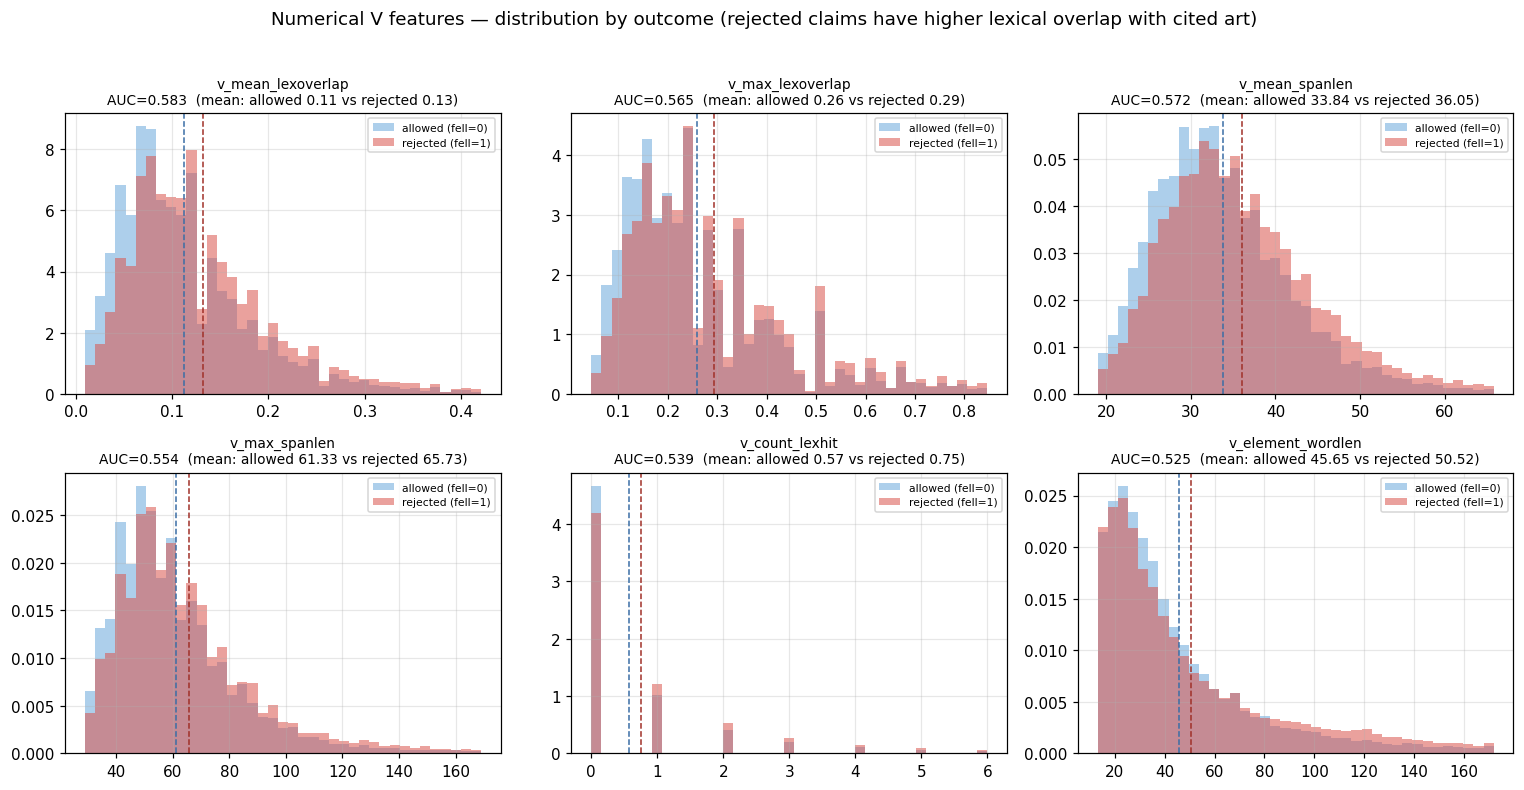

In [23]:
num_V = ['v_mean_lexoverlap', 'v_max_lexoverlap', 'v_mean_spanlen', 'v_max_spanlen', 'v_count_lexhit', 'v_element_wordlen']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), num_V):
    a = auc(pat['fell'], pat[col]); a = max(a, 1 - a)
    lo, hi = pat[col].quantile([0.01, 0.99])
    bins = np.linspace(lo, hi, 40)
    ax.hist(pat.loc[pat.fell == 0, col], bins=bins, density=True, alpha=0.55, label='allowed (fell=0)', color='#6aa9dc')
    ax.hist(pat.loc[pat.fell == 1, col], bins=bins, density=True, alpha=0.55, label='rejected (fell=1)', color='#d9544d')
    m0, m1 = pat.loc[pat.fell == 0, col].mean(), pat.loc[pat.fell == 1, col].mean()
    ax.axvline(m0, c='#3a6ea5', ls='--', lw=1); ax.axvline(m1, c='#a03028', ls='--', lw=1)
    ax.set_title(f'{col}\nAUC={a:.3f}  (mean: allowed {m0:.2f} vs rejected {m1:.2f})', fontsize=9)
    ax.legend(fontsize=7)
plt.suptitle('Numerical V features — distribution by outcome (rejected claims have higher lexical overlap with cited art)', y=1.02)
plt.tight_layout(); plt.show()

In [24]:
# numeric summary of the bonus: effect direction + separation for each numerical V feature
bonus = []
for col in num_V:
    m0 = pat.loc[pat.fell == 0, col].mean(); m1 = pat.loc[pat.fell == 1, col].mean()
    sd = pat[col].std() + 1e-9
    a = auc(pat['fell'], pat[col])
    bonus.append(dict(feature=col, mean_allowed=round(m0, 3), mean_rejected=round(m1, 3),
                      cohen_d=round((m1 - m0) / sd, 3), auc=round(max(a, 1 - a), 3),
                      higher_when=('rejected' if m1 > m0 else 'allowed')))
pd.DataFrame(bonus).sort_values('auc', ascending=False).reset_index(drop=True)

,feature,mean_allowed,mean_rejected,cohen_d,auc,higher_when
0,v_mean_lexoverlap,0.113,0.132,0.240,0.583,rejected
1,v_mean_spanlen,33.842,36.051,0.229,0.572,rejected
2,v_max_lexoverlap,0.259,0.294,0.202,0.565,rejected
3,v_max_spanlen,61.326,65.728,0.160,0.554,rejected
4,v_count_lexhit,0.568,0.748,0.140,0.539,rejected
5,v_element_wordlen,45.655,50.517,0.135,0.525,rejected


**Bonus takeaway:** the strongest patent V signal is `v_mean_lexoverlap` — rejected claims' cited references share more claim terminology with the claim than allowed claims' retrieved references do. It's a real, continuous, monotone effect (positive Cohen's d), and it is the single most predictive feature in the whole patent feature set — slightly ahead of any LLM disclosure judgment. That is the mechanical reason patents behaves like a **thin/rule-heavy** domain (V≈A) rather than a thick/judgment one.